In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    log_loss,
    roc_auc_score,
    roc_curve
)

In [77]:
df = pd.read_csv(
    "../../employee_data.csv"
)

df.head()

,Employee_ID,Name,Gender,Age,Department,City,Experience_Years,Education_Level,Job_Level,Salary,Performance_Score,Joining_Date,Is_Remote,Employment_Type,Monthly_Work_Hours,Projects_Completed,Training_Hours,Satisfaction_Score,Attrition,Email
0,1001,Farhan Ahmed,Male,38,Marketing,Karachi,4,Intermediate,Senior,111512,7.9,2014-09-18,True,Full-time,169,150,77,1.1,No,farhan.ahmed1001@company.com
1,1002,Farhan Chaudhry,Female,35,Design,Rawalpindi,8,Intermediate,Senior,NaN,6.7,2017-06-27,True,Part-time,183,7,11,2.5,No,farhan.chaudhry1002@company.com
2,1003,Hira Sheikh,Female,23,Design,Lhore,3,MPhil,Junior,56050,NaN,2015-07-24,True,Full-time,177,6,29,4.5,No,hira.sheikh1003@company.com
3,1004,Saad Butt,Female,NaN,Support,Islamabad,6,Master,Senior,118533,NaN,2017-11-02,True,Full-time,188,18,71,1.9,No,NaN
4,1005,Shahzaib Qureshi,Male,35,IT,Peshawar,10,MPhil,Junior,77905,9.3,2021-01-21,True,Full-time,190,30,18,NaN,No,shahzaib.qureshi1005@company.com


In [78]:
print("Shape:", df.shape)



Shape: (520, 20)


In [79]:
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
Employee_ID            0
Name                   0
Gender                 0
Age                   35
Department             0
City                  29
Experience_Years       0
Education_Level        0
Job_Level              0
Salary                26
Performance_Score     21
Joining_Date           0
Is_Remote              0
Employment_Type        0
Monthly_Work_Hours     0
Projects_Completed     0
Training_Hours         0
Satisfaction_Score    18
Attrition              0
Email                 17
dtype: int64


In [80]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Employee_ID             int64
Name                      str
Gender                    str
Age                       str
Department                str
City                      str
Experience_Years        int64
Education_Level           str
Job_Level                 str
Salary                    str
Performance_Score     float64
Joining_Date              str
Is_Remote                 str
Employment_Type           str
Monthly_Work_Hours      int64
Projects_Completed      int64
Training_Hours          int64
Satisfaction_Score    float64
Attrition                 str
Email                     str
dtype: object


In [81]:
print(df.columns.tolist())

['Employee_ID', 'Name', 'Gender', 'Age', 'Department', 'City', 'Experience_Years', 'Education_Level', 'Job_Level', 'Salary', 'Performance_Score', 'Joining_Date', 'Is_Remote', 'Employment_Type', 'Monthly_Work_Hours', 'Projects_Completed', 'Training_Hours', 'Satisfaction_Score', 'Attrition', 'Email']


In [82]:
print(df["Attrition"].value_counts())

print("\nTarget Percentages:")
print(
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Attrition
No     421
Yes     99
Name: count, dtype: int64

Target Percentages:
Attrition
No     80.96
Yes    19.04
Name: proportion, dtype: float64


In [83]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].value_counts()

Attrition
0    421
1     99
Name: count, dtype: int64

In [84]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (520, 19)
y shape: (520,)


In [85]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Name', 'Gender', 'Age', 'Department', 'City', 'Education_Level', 'Job_Level', 'Salary', 'Joining_Date', 'Is_Remote', 'Employment_Type', 'Email']

Numerical Features:
['Employee_ID', 'Experience_Years', 'Performance_Score', 'Monthly_Work_Hours', 'Projects_Completed', 'Training_Hours', 'Satisfaction_Score']


C:\Users\Milon\AppData\Local\Temp\ipykernel_20160\3552009142.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (416, 19)
Testing data: (104, 19)


In [87]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [88]:
print(df["Attrition"].unique())
print(df["Attrition"].isnull().sum())

[0 1]
0


In [89]:
print(y_train.unique())
print(y_train.isnull().sum())

[0 1]
0


In [90]:
print("X dtypes:")
print(X.dtypes)

print("\nMissing values:")
print(X.isnull().sum())

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

X dtypes:
Employee_ID             int64
Name                      str
Gender                    str
Age                       str
Department                str
City                      str
Experience_Years        int64
Education_Level           str
Job_Level                 str
Salary                    str
Performance_Score     float64
Joining_Date              str
Is_Remote                 str
Employment_Type           str
Monthly_Work_Hours      int64
Projects_Completed      int64
Training_Hours          int64
Satisfaction_Score    float64
Email                     str
dtype: object

Missing values:
Employee_ID            0
Name                   0
Gender                 0
Age                   35
Department             0
City                  29
Experience_Years       0
Education_Level        0
Job_Level              0
Salary                26
Performance_Score     21
Joining_Date           0
Is_Remote              0
Employment_Type        0
Monthly_Work_Hours     0
Projects_Compl

In [91]:
X = df.drop(
    columns=[
        "Attrition",
        "Employee_ID",
        "Name",
        "Email",
        "Joining_Date"
    ]
)

y = df["Attrition"]

# Convert numeric-looking columns
X["Age"] = pd.to_numeric(X["Age"], errors="coerce")
X["Salary"] = pd.to_numeric(X["Salary"], errors="coerce")

# Check missing values created after conversion
print(X.isnull().sum())

Gender                 0
Age                   43
Department             0
City                  29
Experience_Years       0
Education_Level        0
Job_Level              0
Salary                31
Performance_Score     21
Is_Remote              0
Employment_Type        0
Monthly_Work_Hours     0
Projects_Completed     0
Training_Hours         0
Satisfaction_Score    18
dtype: int64


In [92]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Gender', 'Department', 'City', 'Education_Level', 'Job_Level', 'Is_Remote', 'Employment_Type']

Numerical Features:
['Age', 'Experience_Years', 'Salary', 'Performance_Score', 'Monthly_Work_Hours', 'Projects_Completed', 'Training_Hours', 'Satisfaction_Score']


C:\Users\Milon\AppData\Local\Temp\ipykernel_20160\3552009142.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (416, 15)
Testing data: (104, 15)


In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [95]:
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Salary"] = X["Salary"].fillna(X["Salary"].median())

print("Remaining missing values:")
print(X.isnull().sum().sum())

Remaining missing values:
68


In [96]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Gender','Age','Department',...,'Projects_Completed','Training_Hours', 'Satisfaction_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [97]:
y_pred = logistic_pipeline.predict(X_test)

y_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred[:10])

print("\nPredicted Probabilities:")
print(y_probability[:10])

Predicted Classes:
[0 0 0 0 0 0 0 0 0 0]

Predicted Probabilities:
[0.25767334 0.21167127 0.24307041 0.35962205 0.09818481 0.1574085
 0.27372389 0.20120447 0.13692726 0.11208149]


In [98]:
threshold = 0.5

y_pred_custom = (
    y_probability >= threshold
).astype(int)

print(y_pred_custom[:10])

[0 0 0 0 0 0 0 0 0 0]


In [99]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.7885


In [100]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", round(precision, 4))

Precision: 0.0


In [101]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", round(recall, 4))

Recall: 0.0


In [102]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", round(f1, 4))

F1 Score: 0.0


In [103]:
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7885
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [104]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[82  2]
 [20  0]]


In [105]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.98      0.88        84
           1       0.00      0.00      0.00        20

    accuracy                           0.79       104
   macro avg       0.40      0.49      0.44       104
weighted avg       0.65      0.79      0.71       104



In [106]:
loss = log_loss(
    y_test,
    y_probability
)

print("Log Loss:", round(loss, 4))

Log Loss: 0.5983


In [107]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("AUC:", round(auc_score, 4))

AUC: 0.3524


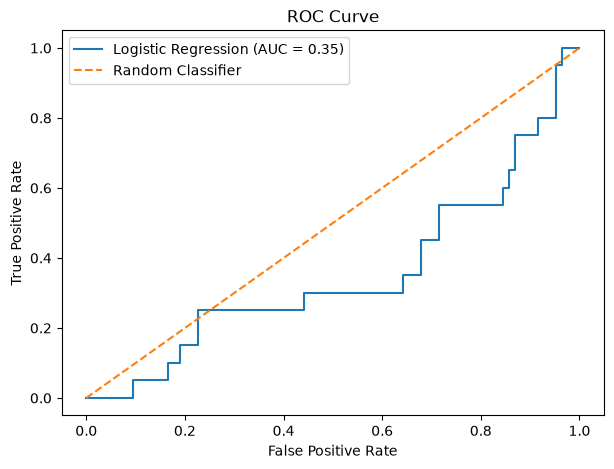

In [108]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [109]:
regularized_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            penalty="l2",
            max_iter=1000,
            random_state=42
        )
    )
])

regularized_pipeline.fit(
    X_train,
    y_train
)

regularized_pred = regularized_pipeline.predict(
    X_test
)

print(
    "Regularized Accuracy:",
    round(
        accuracy_score(y_test, regularized_pred),
        4
    )
)

Regularized Accuracy: 0.7885


f:\machine-learning-beginner-to-advanced\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [110]:
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("Log Loss :", round(loss, 4))
print("AUC      :", round(auc_score, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.7885
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
Log Loss : 0.5983
AUC      : 0.3524
